In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Tensorflow-Models

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1oP3ewZgiatY88SU5esvVcTCqbdfjYu1d/Tensorflow-Models


In [2]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("/content/gdrive/MyDrive/Hugging Face/datasets/excavators/train_cropped")
count_images("/content/gdrive/MyDrive/Hugging Face/datasets/excavators/valid_cropped")

Total images: 657
Total images: 54


In [ ]:
train_json = "/content/gdrive/MyDrive/Hugging Face/datasets/excavators/train_keypoints.json"
valid_json = "/content/gdrive/MyDrive/Hugging Face/datasets/excavators/valid_keypoints.json"

In [ ]:
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import cv2
import os
import math
import random

def visualize_coco_keypoints(json_path, img_dir, num_images=9):
    coco = COCO(json_path)
    img_ids = coco.getImgIds()
    random.shuffle(img_ids)
    num_images = min(num_images, len(img_ids))

    # Find category that has keypoints
    cats = coco.loadCats(coco.getCatIds())
    cat_with_kps = next((cat for cat in cats if 'keypoints' in cat and 'skeleton' in cat), None)

    if not cat_with_kps:
        print("No category with keypoints and skeleton found.")
        return

    keypoint_names = cat_with_kps['keypoints']
    skeleton = cat_with_kps['skeleton']

    cols = 3
    rows = math.ceil(num_images / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for idx in range(num_images):
        img_id = img_ids[idx]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])
        img = cv2.imread(img_path)
        if img is None:
            print(f"Image not found: {img_path}")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ann_ids = coco.getAnnIds(imgIds=img_info['id'])
        anns = coco.loadAnns(ann_ids)

        ax = axes[idx]
        ax.imshow(img)

        for ann in anns:
            if 'keypoints' not in ann:
                continue

            kps = ann['keypoints']
            keypoints_xyv = [(kps[i], kps[i+1], kps[i+2]) for i in range(0, len(kps), 3)]

            # Plot skeleton lines
            for pair in skeleton:
                idx1, idx2 = pair[0] - 1, pair[1] - 1  # 1-based to 0-based
                if idx1 < len(keypoints_xyv) and idx2 < len(keypoints_xyv):
                    x1, y1, v1 = keypoints_xyv[idx1]
                    x2, y2, v2 = keypoints_xyv[idx2]
                    if v1 > 0 and v2 > 0:
                        ax.plot([x1, x2], [y1, y2], 'cyan', linewidth=2)

            # Plot keypoints
            for i, (x, y, v) in enumerate(keypoints_xyv):
                if v > 0:
                    ax.plot(x, y, 'ro' if v == 2 else 'go', markersize=5)
                    ax.text(x + 5, y - 5, keypoint_names[i],
                            fontsize=8,
                            color='blue',
                            ha='left', va='bottom')

        ax.set_title(img_info['file_name'], fontsize=10)
        ax.axis('off')

    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


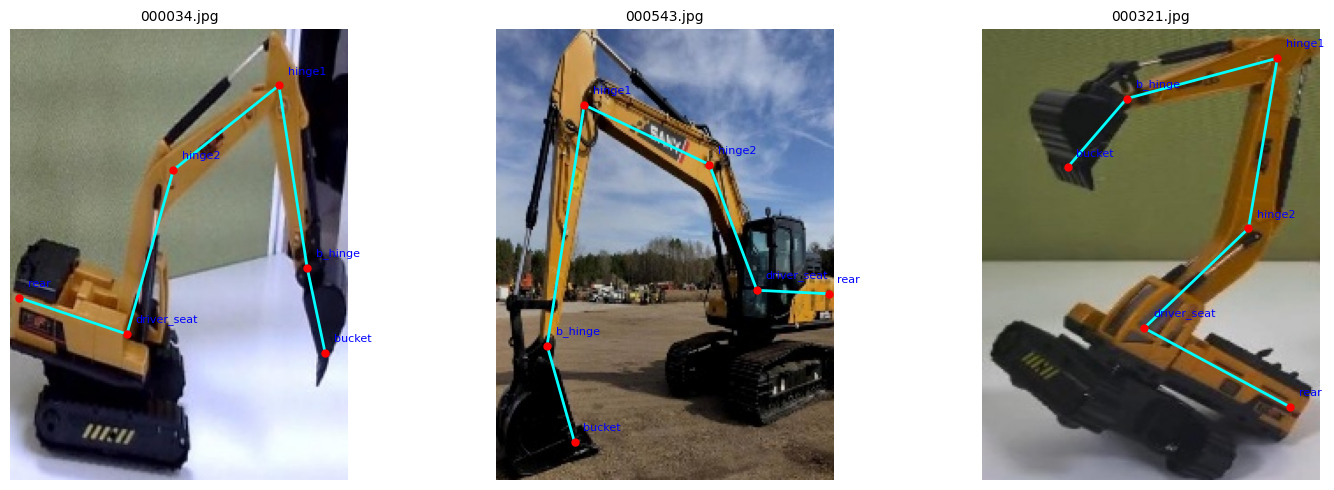

In [ ]:
visualize_coco_keypoints(train_json, "/content/gdrive/MyDrive/Hugging Face/datasets/excavators/train_cropped", num_images=3)

In [ ]:
import json
from pprint import pprint

train_json = "/content/gdrive/MyDrive/Hugging Face/datasets/excavators/train_keypoints.json"

with open(train_json, 'r') as f:
    data = json.load(f)

print("Total images entries:", len(data.get("images", [])))
print("Total annotations:", len(data.get("annotations", [])))
print("\nSample image entry:")
pprint(data["images"][0])
print("\nSample annotation entry:")
pprint(data["annotations"][0])

# Show first 18 numbers of the keypoints for the first annotation (6 keypoints x 3)
kp = data["annotations"][0]["keypoints"]
print("\nFirst 18 elements of keypoints:", kp[:18])

Total images entries: 657
Total annotations: 657

Sample image entry:
{'file_name': '000001.jpg', 'height': 256, 'id': 1, 'width': 192}

Sample annotation entry:
{'area': 49152,
 'bbox': [0, 0, 192, 256],
 'category_id': 1,
 'id': 1,
 'image_id': 1,
 'iscrowd': 0,
 'keypoints': [78.79666431095407,
               238.66710064239828,
               2,
               24.42402826855124,
               53.78247537473233,
               2,
               119.06713780918729,
               57.68058244111348,
               2,
               145.01766784452298,
               131.74571306209853,
               2,
               188.7773851590106,
               100.56030835117774,
               2,
               63.095406360424036,
               181.0298244111349,
               2],
 'num_keypoints': 6}

First 18 elements of keypoints: [78.79666431095407, 238.66710064239828, 2, 24.42402826855124, 53.78247537473233, 2, 119.06713780918729, 57.68058244111348, 2, 145.01766784452298, 131.74571306

In [3]:
import os
import json
import numpy as np
import cv2
from glob import glob
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger

In [4]:
def parse_coco_keypoints(json_path, img_dir, num_keypoints):
    """
    Returns list of tuples: (img_path, coords_normalized)
    coords_normalized: shape (num_keypoints*2,), values in [0,1]
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    # Map image_id -> filename and original size
    id_to_info = {img["id"]: img for img in data["images"]}

    pairs = []
    for ann in data["annotations"]:
        img_id = ann["image_id"]
        img_info = id_to_info[img_id]
        img_path = os.path.join(img_dir, img_info["file_name"])
        orig_w, orig_h = img_info["width"], img_info["height"]

        # parse keypoints (x,y,v)
        kpts = np.array(ann["keypoints"], dtype=np.float32).reshape(-1,3)
        xy = kpts[:, :2]  # x,y
        # normalize to [0,1] using original image size
        xy[:,0] /= orig_w
        xy[:,1] /= orig_h

        pairs.append((img_path, xy.flatten()))

    return pairs

def read_image_landmarks(image_path, landmarks):
    """Load and resize image; landmarks are already normalized [0,1]."""
    if isinstance(image_path, bytes):
        image_path = image_path.decode()

    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (image_w, image_h))
    image = image / 255.0
    image = image.astype(np.float32)

    # landmarks are normalized, so keep as-is
    coords = np.array(landmarks, dtype=np.float32).flatten()
    return image, coords

def preprocess(x, y):
    def f(x, y):
        return read_image_landmarks(x, y)
    image, landmarks = tf.numpy_function(f, [x, y], [tf.float32, tf.float32])
    image.set_shape([image_h, image_w, 3])
    landmarks.set_shape([num_landmarks * 2])
    return image, landmarks

def tf_dataset(image_paths, keypoints, batch=8):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, keypoints))
    ds = ds.shuffle(buffer_size=5000).map(preprocess)
    ds = ds.batch(batch).prefetch(2)
    return ds

In [5]:
""" Hyperparameters """
batch_size = 32
lr = 1e-3
image_h, image_w = 512, 512
num_landmarks = 6
input_shape = (image_h, image_w, 3)

train_json = "/content/gdrive/MyDrive/Hugging Face/datasets/excavators/train_keypoints.json"
valid_json = "/content/gdrive/MyDrive/Hugging Face/datasets/excavators/valid_keypoints.json"

train_img_dir = "/content/gdrive/MyDrive/Hugging Face/datasets/excavators/train_cropped"
valid_img_dir = "/content/gdrive/MyDrive/Hugging Face/datasets/excavators/valid_cropped"

train_pairs = parse_coco_keypoints(train_json, train_img_dir, num_keypoints=num_landmarks)
valid_pairs = parse_coco_keypoints(valid_json, valid_img_dir, num_keypoints=num_landmarks)

train_x, train_y = zip(*train_pairs)
valid_x, valid_y = zip(*valid_pairs)

print(f"Train: {len(train_x)}, Valid: {len(valid_x)}")

train_ds = tf_dataset(list(train_x), np.array(train_y), batch=batch_size)
valid_ds = tf_dataset(list(valid_x), np.array(valid_y), batch=batch_size)

Train: 657, Valid: 54


In [ ]:
print("First 10 GT coords:", train_y[0][:10])


First 10 GT coords: [0.4103993  0.93229336 0.12720849 0.21008779 0.6201413  0.22531478
 0.75530034 0.5146317  0.9832156  0.3928137 ]


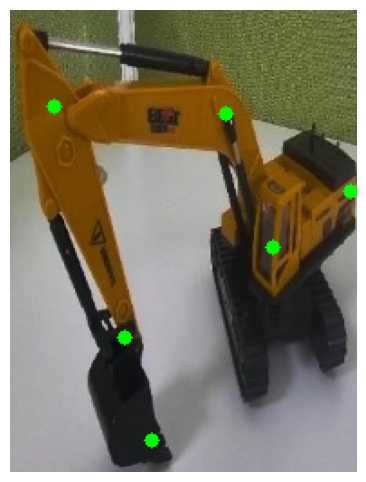

In [ ]:
import matplotlib.pyplot as plt

def visualize_keypoints(image_path, keypoints, normalized=False, radius=4, color=(0,255,0)):
    """Show image with keypoints drawn."""
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape
    pts = keypoints.reshape(-1, 2).copy()

    if normalized:  # denormalize back
        pts[:, 0] *= w
        pts[:, 1] *= h

    for (x, y) in pts:
        if x > 1 and y > 1:  # skip invalid
            cv2.circle(img, (int(x), int(y)), radius, color, -1)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Take one sample
img_path = train_x[0]
gt = train_y[0]   # shape (num_landmarks*2,)

visualize_keypoints(img_path, gt, normalized=True)

In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers as L
import tensorflow as tf

def build_model(input_shape, num_landmarks):
    inputs = L.Input(input_shape)

    # 🔹 Backbone: EfficientNetB0
    backbone = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inputs)
    backbone.trainable = True

    x = backbone.output
    x = L.GlobalAveragePooling2D()(x)
    x = L.Dropout(0.2)(x)
    outputs = L.Dense(num_landmarks * 2, activation="sigmoid")(x)

    model = tf.keras.models.Model(inputs, outputs)
    return model

""" Model """
model = build_model(input_shape, num_landmarks)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 512, 512,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 512, 512,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 512, 512,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 513, 513,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 256, 256,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 256, 256,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 256, 256,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 256, 256,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 256, 256,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 256, 256,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 256, 256,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 256, 256,  │        512 │ block1a_se_excit

 Total params: 4,064,943 (15.51 MB)

 Trainable params: 4,022,920 (15.35 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(lr),
    loss=tf.keras.losses.Huber(),   # or "mse"
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
    ]
)
checkpoint_filepath = "EfficientNetB0_excavator_keypoints.weights.h5"

""" Training """
callbacks = [
    ModelCheckpoint(checkpoint_filepath, monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-7, verbose=1),
]

In [ ]:
# with loss=tf.keras.losses.Huber()
num_epochs = 30

history = model.fit(train_ds,
    validation_data=valid_ds,
    epochs=num_epochs,
    callbacks=callbacks
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0211 - mae: 0.1576   
Epoch 1: val_loss improved from inf to 0.06585, saving model to EfficientNetB0_excavator_keypoints.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 197s 6s/step - loss: 0.0208 - mae: 0.1558 - val_loss: 0.0659 - val_mae: 0.2984 - learning_rate: 0.0010
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - loss: 0.0038 - mae: 0.0641
Epoch 2: val_loss improved from 0.06585 to 0.06363, saving model to EfficientNetB0_excavator_keypoints.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 439ms/step - loss: 0.0038 - mae: 0.0642 - val_loss: 0.0636 - val_mae: 0.2996 - learning_rate: 0.0010
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - loss: 0.0026 - mae: 0.0542
Epoch 3: val_loss did not improve from 0.06363
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 391ms/step - loss: 0.0026 - mae: 0.0543 - val_loss: 0.0680 - val_mae: 0.3111 - learning_rate: 0.0010
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - loss: 0.0021 - mae: 0.0490
Epoch 4: val

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # smaller LR
    loss=tf.keras.losses.Huber(),   # or "mse"
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
    ]
)
checkpoint_filepath = "EfficientNetB0_excavator_keypoints.weights.h5"

""" Training """
callbacks = [
    ModelCheckpoint(checkpoint_filepath, monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-7, verbose=1),
]

In [ ]:
# with loss=tf.keras.losses.Huber()
num_epochs = 30

history = model.fit(train_ds,
    validation_data=valid_ds,
    epochs=num_epochs,
    callbacks=callbacks
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 5.3581e-04 - mae: 0.0255   
Epoch 1: val_loss improved from inf to 0.00929, saving model to EfficientNetB0_excavator_keypoints.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - loss: 5.3783e-04 - mae: 0.0256 - val_loss: 0.0093 - val_mae: 0.1046 - learning_rate: 1.0000e-05
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - loss: 5.1633e-04 - mae: 0.0245
Epoch 2: val_loss improved from 0.00929 to 0.00839, saving model to EfficientNetB0_excavator_keypoints.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 436ms/step - loss: 5.1866e-04 - mae: 0.0246 - val_loss: 0.0084 - val_mae: 0.0984 - learning_rate: 1.0000e-05
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - loss: 6.4806e-04 - mae: 0.0279
Epoch 3: val_loss improved from 0.00839 to 0.00508, saving model to EfficientNetB0_excavator_keypoints.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 437ms/step - loss: 6.4693e-04 - mae: 0.0279 - val_loss: 0.0051 - val_mae: 0.0708 - learning_rate: 1.

In [9]:
# Generate predictions for all images in the validation set
checkpoint_filepath = "EfficientNetB0_excavator_keypoints.weights.h5"
model.load_weights(checkpoint_filepath)

In [ ]:
import random
import matplotlib.pyplot as plt

def plot_landmarks(image, landmarks, color=(255, 0, 0)):
    h, w, _ = image.shape
    radius = int(h * 0.02)
    for i in range(0, len(landmarks), 2):
        x = int(landmarks[i] * w)
        y = int(landmarks[i+1] * h)
        image = cv2.circle(image, (x, y), radius, color, -1)
    return image

In [ ]:
def inference_fn(samples):
    plt.figure(figsize=(15, 8))

    for idx, (img_path, gt) in enumerate(samples, 1):
        # Original image
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        h, w, _ = image.shape

        # Preprocess for model
        inp = cv2.resize(image, (image_w, image_h))
        inp = inp / 255.0
        inp = np.expand_dims(inp.astype(np.float32), axis=0)

        # Ground truth landmarks are already provided in 'gt'

        # Prediction
        pred = model.predict(inp, verbose=0)[0]

        # Draw
        gt_img = plot_landmarks(image.copy(), gt, color=(0, 255, 0))   # green = GT
        pred_img = plot_landmarks(image.copy(), pred, color=(0, 0, 255)) # red = Pred

        # Show side by side
        cat = np.concatenate([gt_img, pred_img], axis=1)
        cat = cv2.cvtColor(cat, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 2, idx)
        plt.imshow(cat)
        plt.axis("off")
        plt.title(f"Sample {idx}: GT (left) vs Pred (right)")

    plt.tight_layout()
    plt.show()

In [ ]:
img, gt = read_image_landmarks(train_x[0], train_y[0])
pred = model.predict(img[np.newaxis], verbose=0)[0]
print("GT[0:10]:", gt[:10])
print("Pred[0:10]:", pred[:10])

GT[0:10]: [0.4103993  0.93229336 0.12720849 0.21008779 0.6201413  0.22531478
 0.75530034 0.5146317  0.9832156  0.3928137 ]
Pred[0:10]: [0.3787519  0.92956394 0.11703672 0.2035362  0.6130637  0.20879018
 0.75073946 0.5038136  0.9602006  0.37958422]


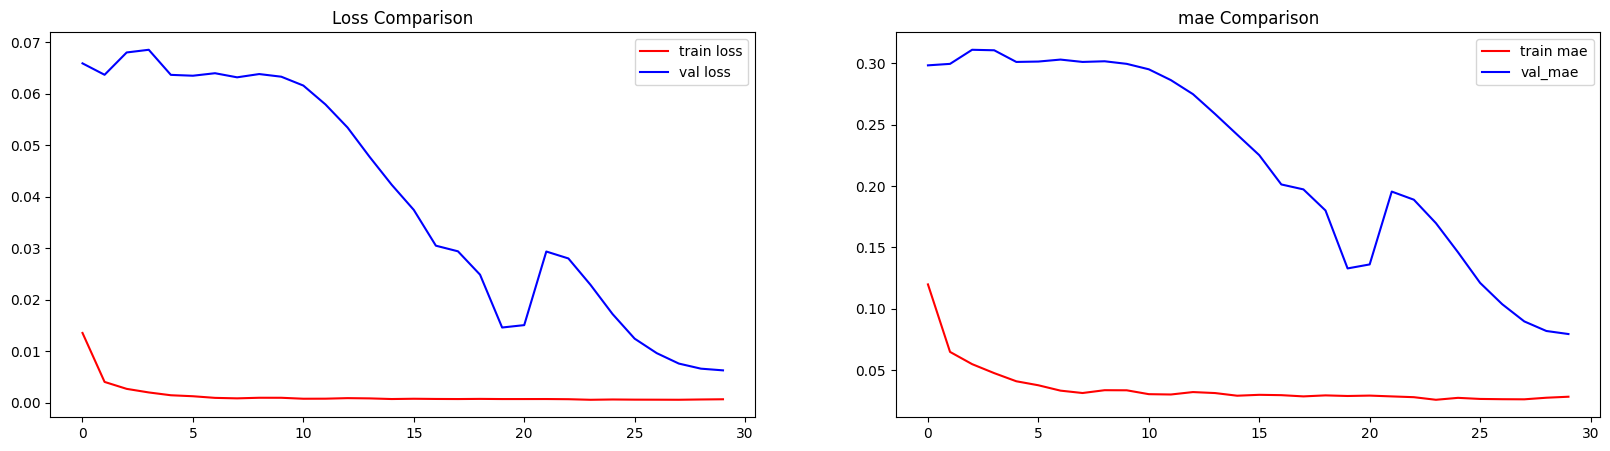

In [ ]:
import matplotlib.pyplot as plt
fig, axis = plt.subplots(1, 2, figsize=(20, 5))
axis[0].plot(history.history["loss"], color='r', label = 'train loss')
axis[0].plot(history.history["val_loss"], color='b', label = 'val loss')
axis[0].set_title('Loss Comparison')
axis[0].legend()
axis[1].plot(history.history["mae"], color='r', label = 'train mae')
axis[1].plot(history.history["val_mae"], color='b', label = 'val_mae')
axis[1].set_title('mae Comparison')
axis[1].legend()

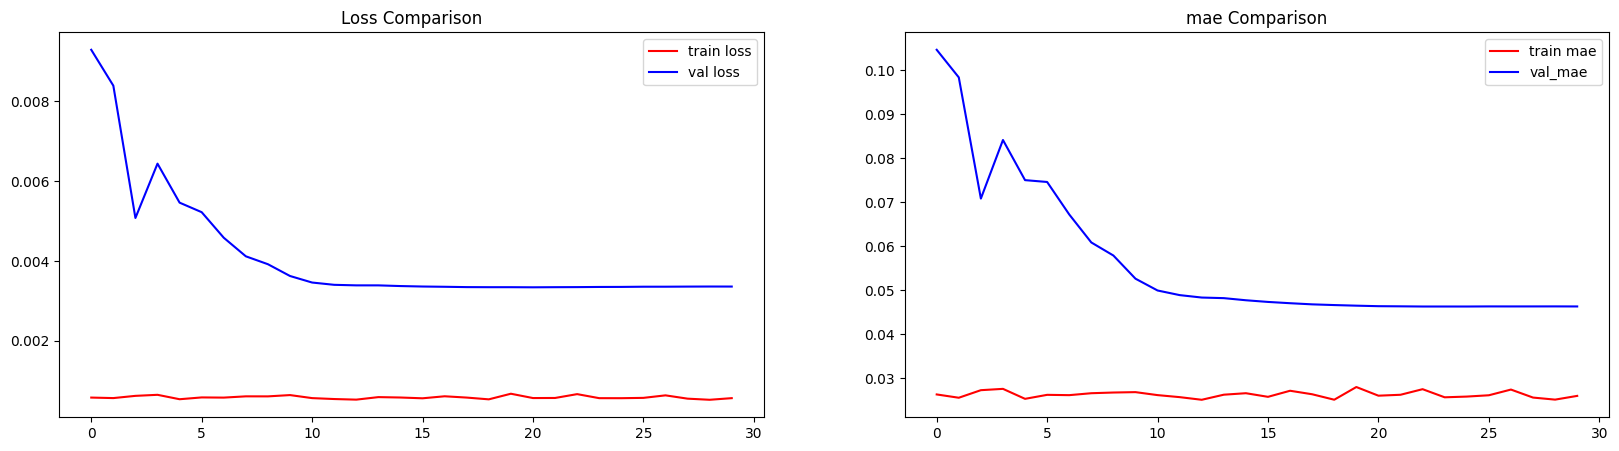

In [ ]:
import matplotlib.pyplot as plt
fig, axis = plt.subplots(1, 2, figsize=(20, 5))
axis[0].plot(history.history["loss"], color='r', label = 'train loss')
axis[0].plot(history.history["val_loss"], color='b', label = 'val loss')
axis[0].set_title('Loss Comparison')
axis[0].legend()
axis[1].plot(history.history["mae"], color='r', label = 'train mae')
axis[1].plot(history.history["val_mae"], color='b', label = 'val_mae')
axis[1].set_title('mae Comparison')
axis[1].legend()

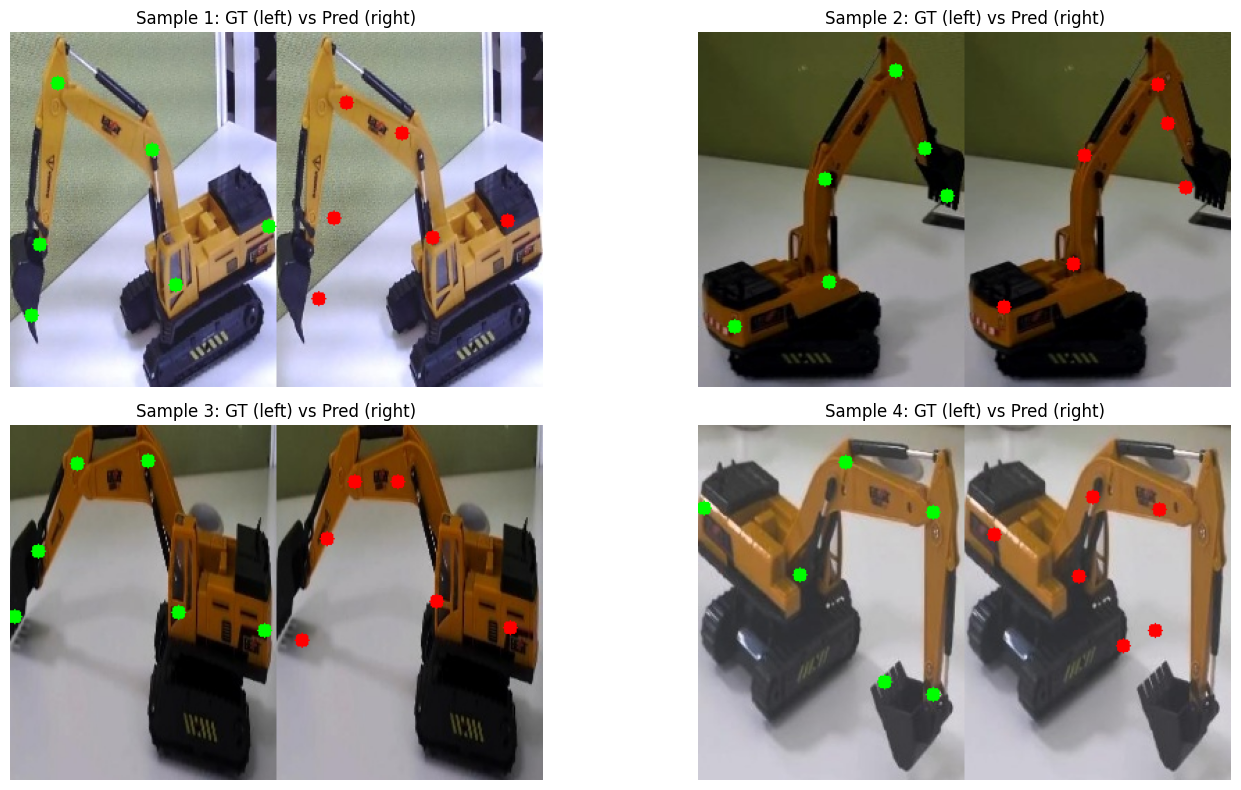

In [ ]:
# Pick 4 random validation samples
samples = random.sample(list(zip(train_x, train_y)), 4)
inference_fn(samples)

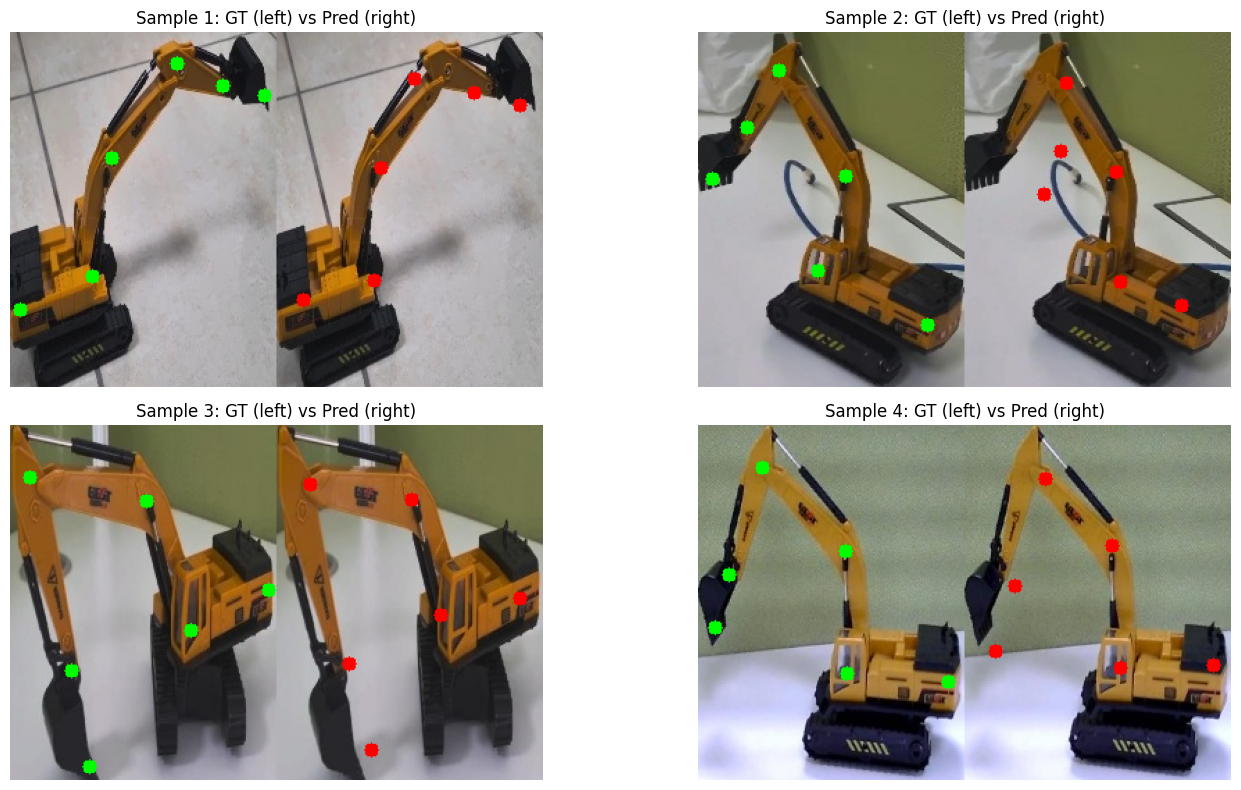

In [ ]:
# Pick 4 random validation samples
samples = random.sample(list(zip(valid_x, valid_y)), 4)
inference_fn(samples)

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

def plot_landmarks(image, landmarks, color=(255, 0, 0)):
    h, w, _ = image.shape
    radius = max(1, int(h * 0.02))
    for i in range(0, len(landmarks), 2):
        x = int(landmarks[i] * w)
        y = int(landmarks[i+1] * h)
        image = cv2.circle(image, (x, y), radius, color, -1)
    return image

def inference_folder(folder, n_samples=4):
    # Collect only image files
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png"))]
    samples = random.sample(files, min(n_samples, len(files)))

    rows = (len(samples) + 3) // 4   # ceiling division
    plt.figure(figsize=(15, 4 * rows))

    for idx, img_file in enumerate(samples, 1):
        img_path = os.path.join(folder, img_file)
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        h, w, _ = image.shape

        # Preprocess for model
        inp = cv2.resize(image, (image_w, image_h))
        inp = inp / 255.0
        inp = np.expand_dims(inp.astype(np.float32), axis=0)

        # Prediction
        pred = model.predict(inp, verbose=0)[0]

        # Draw prediction only
        pred_img = plot_landmarks(image.copy(), pred, color=(0, 0, 255))
        pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

        # Plot
        plt.subplot(rows, 4, idx)
        plt.imshow(pred_img)
        plt.axis("off")
        plt.title(f"Pred {idx}")

    plt.tight_layout()
    plt.show()

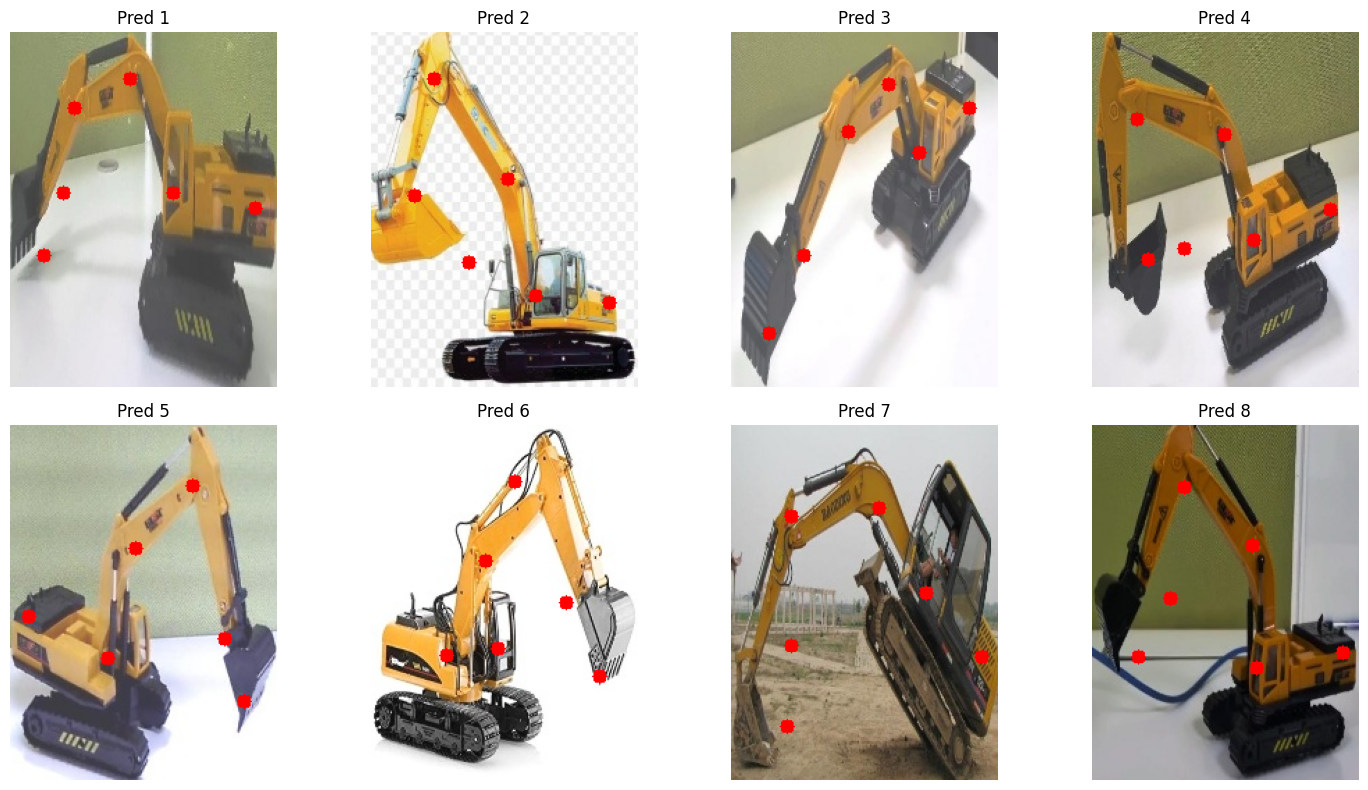

In [ ]:
# Run inference
inference_folder("/content/gdrive/MyDrive/Hugging Face/datasets/excavators/train_cropped", n_samples=8)

In [10]:
# Serialize the model as a SavedModel.
# Use model.export for Keras models
model.export("EfficientNetB0_excavator_keypoints")

import tensorflow as tf
# Convert to TFLite. This form of quantization is called
# post-training dynamic-range quantization in TFLite.
converter = tf.lite.TFLiteConverter.from_saved_model("EfficientNetB0_excavator_keypoints")
# No optimizations
tflite_model = converter.convert()
open("EfficientNetB0_excavator_keypoints.tflite", "wb").write(tflite_model)

Saved artifact at 'EfficientNetB0_excavator_keypoints'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  135994266705680: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135994266707216: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135994499422672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135994499425168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135994499424784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135994499425936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135994499422288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135994499425744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135994499427856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135994499428048: TensorSpec(shape=(), dtype=tf.

16087140

In [14]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="EfficientNetB0_excavator_keypoints.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Get input size (h, w, c)
input_shape = input_details[0]['shape'][1:3]

def plot_landmarks(image, landmarks, color=(255, 0, 0)):
    h, w, _ = image.shape
    radius = max(1, int(h * 0.02))
    for i in range(0, len(landmarks), 2):
        x = int(landmarks[i] * w)
        y = int(landmarks[i+1] * h)
        image = cv2.circle(image, (x, y), radius, color, -1)
    return image

def preprocess_image(img_path, target_size):
    img = Image.open(img_path).convert("RGB").resize(target_size, Image.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0   # normalize
    return arr

def run_tflite_inference(img_path):
    img = preprocess_image(img_path, tuple(input_shape))
    inp = np.expand_dims(img, axis=0)  # [1,h,w,c]

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]

    return output  # already normalized landmark coords [x1,y1,...]

def inference_folder_tflite(folder, n_samples=4):
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png"))]
    samples = random.sample(files, min(n_samples, len(files)))

    rows = (len(samples) + 3) // 4
    plt.figure(figsize=(15, 4 * rows))

    for idx, img_file in enumerate(samples, 1):
        img_path = os.path.join(folder, img_file)
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)

        # Predict with TFLite model
        pred = run_tflite_inference(img_path)

        # Draw prediction
        pred_img = plot_landmarks(image.copy(), pred, color=(0, 0, 255))
        pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, 4, idx)
        plt.imshow(pred_img)
        plt.axis("off")
        plt.title(f"Pred {idx}")

    plt.tight_layout()
    plt.show()

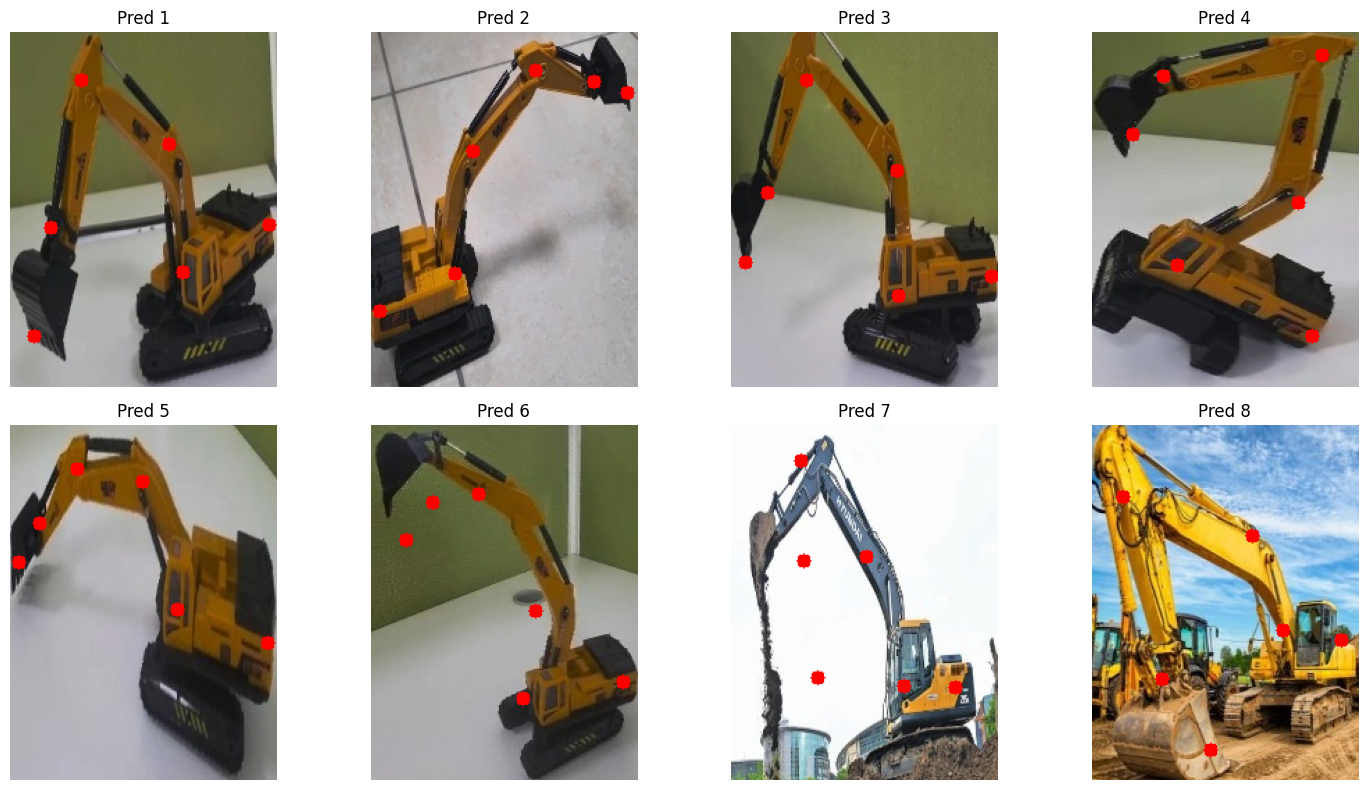

In [15]:
# Example usage
inference_folder_tflite("/content/gdrive/MyDrive/Hugging Face/datasets/excavators/valid_cropped", n_samples=8)

In [18]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="EfficientNetB0_excavator_keypoints.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Get input size (h, w, c)
input_shape = input_details[0]['shape'][1:3]

def plot_landmarks_with_skeleton(image, landmarks):
    """
    Draw 6 keypoints with fixed colors and a custom skeleton.
    landmarks: normalized [x1,y1,...,x6,y6]
    """
    h, w, _ = image.shape
    radius = max(1, int(h * 0.02))

    # Fixed colors for 6 points (BGR)
    point_colors = [
        (0, 0, 255),      # red
        (0, 255, 0),      # green
        (255, 0, 0),      # blue
        (0, 255, 255),    # yellow
        (255, 0, 255),    # magenta
        (255, 255, 255),    # white
    ]

    # Define skeleton as pairs of indices
    SKELETON = [(0,5), (5,1), (1,2), (2,3), (3,4)]

    # Draw points
    pts = []
    for i in range(6):
        x = int(landmarks[i*2] * w)
        y = int(landmarks[i*2+1] * h)
        pts.append((x, y))
        image = cv2.circle(image, (x, y), radius, point_colors[i], -1)

    # Draw skeleton with cyan lines
    skeleton_color = (255, 255, 0)  # cyan
    for (i, j) in SKELETON:
        if i < len(pts) and j < len(pts):
            cv2.line(image, pts[i], pts[j], skeleton_color, 2)

    return image

def preprocess_image(img_path, target_size):
    img = Image.open(img_path).convert("RGB").resize(target_size, Image.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0   # normalize
    return arr

def run_tflite_inference(img_path):
    img = preprocess_image(img_path, tuple(input_shape))
    inp = np.expand_dims(img, axis=0)  # [1,h,w,c]

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]

    return output  # already normalized landmark coords [x1,y1,...]

def inference_folder_tflite(folder, n_samples=4):
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png"))]
    samples = random.sample(files, min(n_samples, len(files)))

    rows = (len(samples) + 3) // 4
    plt.figure(figsize=(15, 4 * rows))

    for idx, img_file in enumerate(samples, 1):
        img_path = os.path.join(folder, img_file)
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)

        # Predict with TFLite model
        pred = run_tflite_inference(img_path)

        # Draw prediction
        pred_img = plot_landmarks_with_skeleton(image.copy(), pred)
        pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, 4, idx)
        plt.imshow(pred_img)
        plt.axis("off")
        plt.title(f"Pred {idx}")

    plt.tight_layout()
    plt.show()

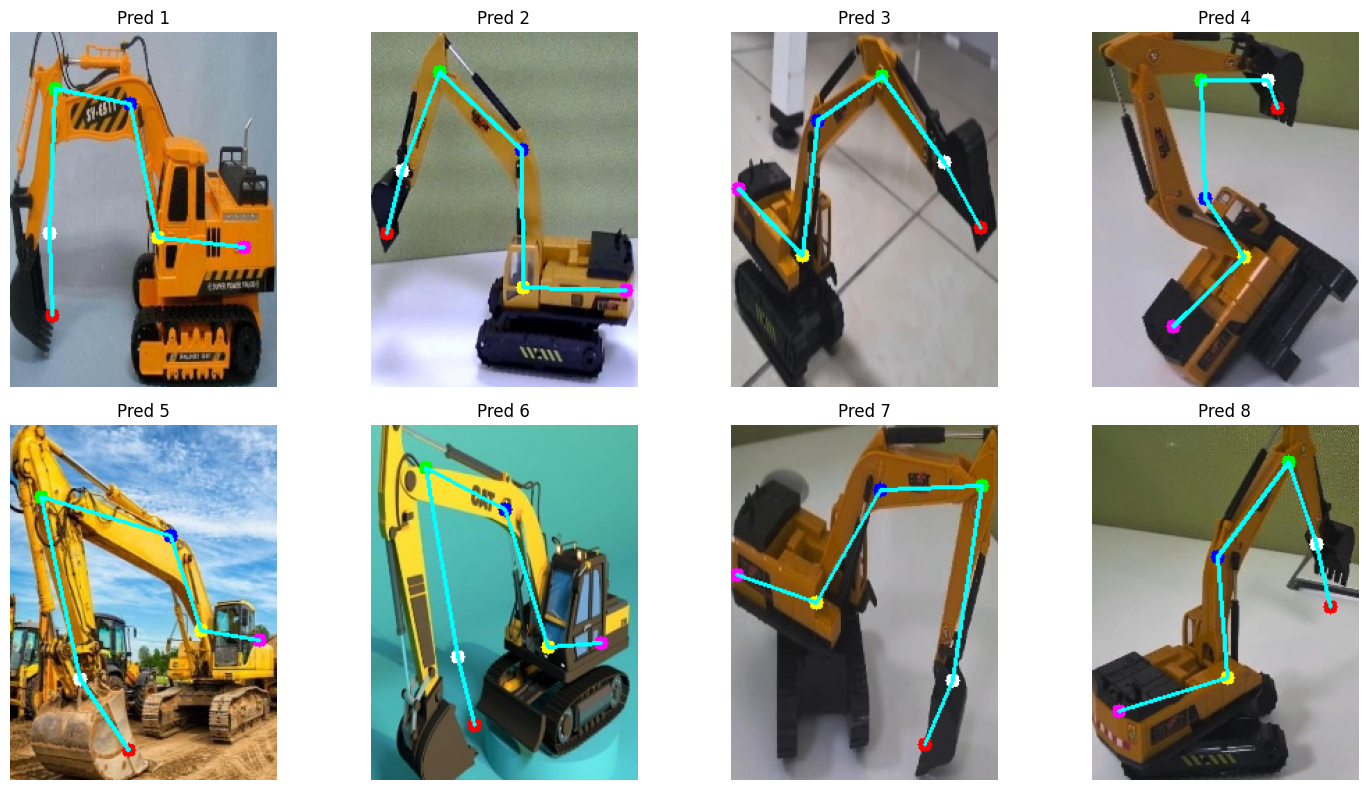

In [19]:
# Example usage
inference_folder_tflite("/content/gdrive/MyDrive/Hugging Face/datasets/excavators/valid_cropped", n_samples=8)

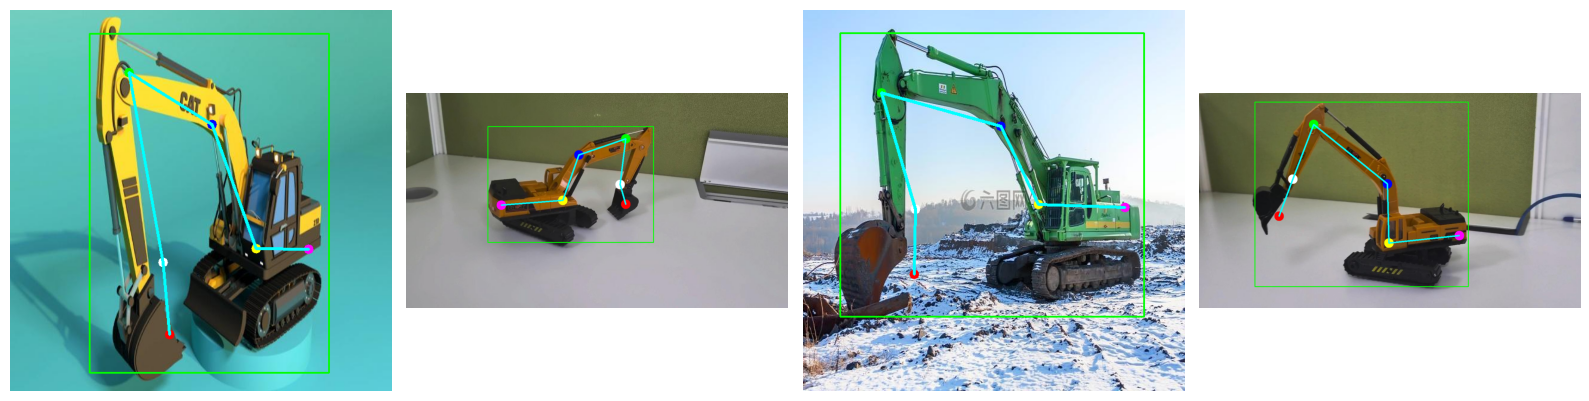

In [21]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import tensorflow as tf

# === CONFIG ===
IMG_DIR = Path("excavator/valid/")              # Folder containing images
TXT_FILE = Path("excavator/res_excavator_valid.txt")  # Annotation file: fname,xmin,ymin,xmax,ymax
MODEL_PATH = "EfficientNetB0_excavator_keypoints.tflite"
NUM_SAMPLES = 4

# === LOAD TFLITE MODEL ===
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_shape = input_details[0]['shape'][1:3]  # (h, w)

# === FUNCTIONS ===
def preprocess_image(img_crop, target_size):
    """Resize + normalize cropped bbox region for inference"""
    img = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
    arr = img.astype(np.float32) / 255.0
    return np.expand_dims(arr, axis=0)

def run_tflite_inference(img_crop):
    """Run TFLite model on cropped bbox image"""
    inp = preprocess_image(img_crop, tuple(input_shape))
    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]
    return output  # normalized [x1,y1,...,x6,y6]

def plot_landmarks_with_skeleton(image, landmarks_abs, bbox):
    """Draw keypoints and skeleton on the full image"""
    xmin, ymin, xmax, ymax = bbox
    radius = max(2, int(0.013 * max(image.shape[:2])))

    # Fixed colors for 6 keypoints
    point_colors = [
        (0, 0, 255),     # red
        (0, 255, 0),     # green
        (255, 0, 0),     # blue
        (0, 255, 255),   # yellow
        (255, 0, 255),   # magenta
        (255, 255, 255)  # white
    ]

    SKELETON = [(0,5), (5,1), (1,2), (2,3), (3,4)]

    pts = []
    for i in range(6):
        x, y = landmarks_abs[i*2], landmarks_abs[i*2 + 1]
        pts.append((int(x), int(y)))
        cv2.circle(image, pts[-1], radius, point_colors[i], -1)

    for (i, j) in SKELETON:
        if i < len(pts) and j < len(pts):
            cv2.line(image, pts[i], pts[j], (255, 255, 0), 3)

    # Draw bbox
    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    return image

# === MAIN PIPELINE ===
# Load bbox annotations
with open(TXT_FILE, "r") as f:
    lines = [line.strip() for line in f.readlines() if line.strip()]

samples = random.sample(lines, min(NUM_SAMPLES, len(lines)))

plt.figure(figsize=(16, 6))

for i, line in enumerate(samples):
    fname, xmin, ymin, xmax, ymax = line.split(",")
    xmin, ymin, xmax, ymax = map(int, [xmin, ymin, xmax, ymax])
    img_path = IMG_DIR / fname
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    # Crop bbox region
    crop = img[ymin:ymax, xmin:xmax]
    if crop.size == 0:
        continue

    # Run keypoint regression
    preds = run_tflite_inference(crop)

    # Convert normalized [0-1] keypoints to absolute coords in full image
    crop_h, crop_w = crop.shape[:2]
    abs_landmarks = []
    for j in range(6):
        x_rel = preds[j*2] * crop_w + xmin
        y_rel = preds[j*2+1] * crop_h + ymin
        abs_landmarks.extend([x_rel, y_rel])

    # Draw keypoints + bbox
    vis_img = plot_landmarks_with_skeleton(img.copy(), abs_landmarks, (xmin, ymin, xmax, ymax))
    vis_img_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, NUM_SAMPLES, i + 1)
    plt.imshow(vis_img_rgb)
    plt.axis("off")

plt.tight_layout()
plt.show()